# **IMPORT LIBRARY**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score, f1_score
import joblib


# **Load Dataset**

In [2]:
# Load dataset
df = pd.read_csv('dashboard/diabets_dataset_clean.csv')
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,0,25.19,6.6,140,0
1,0,54.0,0,0,-1,27.32,6.6,80,0
2,1,28.0,0,0,0,27.32,5.7,158,0
3,0,36.0,0,0,2,23.45,5.0,155,0
4,1,76.0,1,1,2,20.14,4.8,155,0


# **Pisahkan Fitur dan Label**

In [3]:
X = df.drop(columns='diabetes', axis=1)
y = df['diabetes']

# **Feature Scaling (StandardScaler)**

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Evaluasi Sebelum RFE**

In [5]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=2)

# Model training tanpa RFE
classifier_full = SVC(kernel='linear')
classifier_full.fit(X_train_full, y_train_full)

# Evaluasi akurasi
y_train_full_pred = classifier_full.predict(X_train_full)
y_test_full_pred = classifier_full.predict(X_test_full)

train_acc_full = accuracy_score(y_train_full, y_train_full_pred)
test_acc_full = accuracy_score(y_test_full, y_test_full_pred)

print("=== Evaluasi Sebelum RFE ===")
print("Train Accuracy (full):", train_acc_full)
print("Test Accuracy (full):", test_acc_full)

print("=== Classification Report Sebelum RFE ===")
print(classification_report(y_test_full, y_test_full_pred))

=== Evaluasi Sebelum RFE ===
Train Accuracy (full): 0.959267252587238
Test Accuracy (full): 0.9600104004160166
=== Classification Report Sebelum RFE ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17534
           1       0.92      0.60      0.72      1696

    accuracy                           0.96     19230
   macro avg       0.94      0.80      0.85     19230
weighted avg       0.96      0.96      0.96     19230



# **Feature Selection dengan RFE**

In [6]:
# Recursive Feature Elimination 
svc_estimator = SVC(kernel='linear')
selector = RFE(estimator=svc_estimator, n_features_to_select=5)
X_selected = selector.fit_transform(X_scaled, y)

# nama fitur yang dipilih
selected_features = X.columns[selector.support_]
print("Selected features:", selected_features.tolist())

Selected features: ['age', 'hypertension', 'bmi', 'HbA1c_level', 'blood_glucose_level']


# **Split Data Training dan Testing**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, stratify=y, random_state=2)

# **Latih Model SVM**

In [8]:
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)

SVC(kernel='linear')

# **Evaluasi Akurasi Training dan Testing**

In [9]:
y_train_pred = classifier.predict(X_train)
y_test_pred = classifier.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("=== Classification Report Sesudah RFE ===")
print(classification_report(y_test, y_test_pred))


Train Accuracy: 0.9590592334494773
Test Accuracy: 0.9592303692147686
=== Classification Report Sesudah RFE ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17534
           1       0.92      0.59      0.72      1696

    accuracy                           0.96     19230
   macro avg       0.94      0.79      0.85     19230
weighted avg       0.96      0.96      0.96     19230



# **Evaluasi Lanjutan**

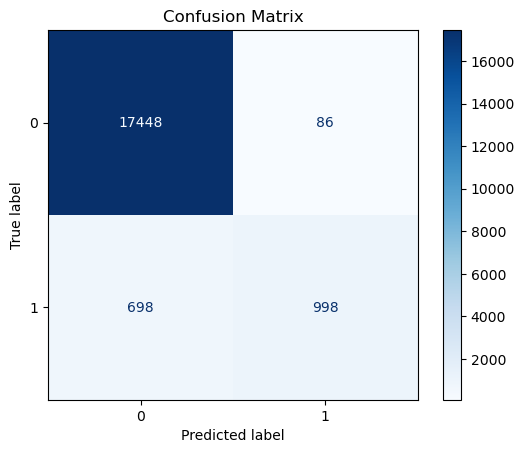

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17534
           1       0.92      0.59      0.72      1696

    accuracy                           0.96     19230
   macro avg       0.94      0.79      0.85     19230
weighted avg       0.96      0.96      0.96     19230



In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_test_pred))

# **Bandingkan hasil akurasi, recall, f1**

In [11]:

print("F1 Score (Sebelum RFE):", f1_score(y_test_full, y_test_full_pred))
print("Recall (Sebelum RFE):", recall_score(y_test_full, y_test_full_pred))

print("F1 Score (Sesudah RFE):", f1_score(y_test, y_test_pred))
print("Recall (Sesudah RFE):", recall_score(y_test, y_test_pred))


F1 Score (Sebelum RFE): 0.724865831842576
Recall (Sebelum RFE): 0.5972877358490566
F1 Score (Sesudah RFE): 0.7179856115107913
Recall (Sesudah RFE): 0.5884433962264151


# **Visualisasi Learning Curve**

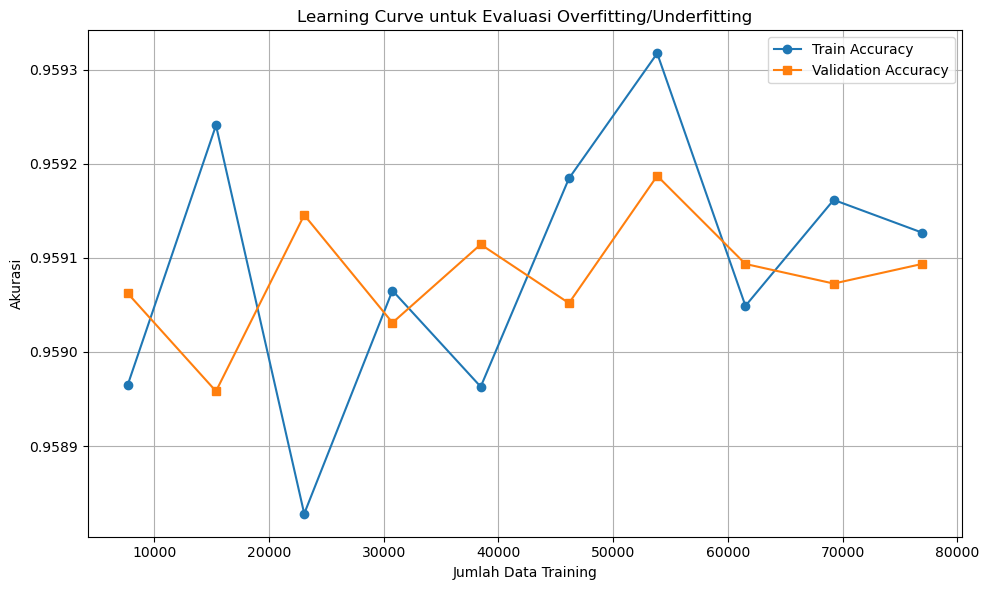

In [12]:
train_sizes, train_scores, test_scores = learning_curve(
    classifier, X_selected, y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

# Hitung rata-rata skor
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train Accuracy', marker='o')
plt.plot(train_sizes, test_mean, label='Validation Accuracy', marker='s')
plt.title('Learning Curve untuk Evaluasi Overfitting/Underfitting')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Akurasi')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


# **Simpan Model dan Komponen Pendukung**

In [13]:
joblib.dump(classifier, 'model/diabetes_model.sav')
joblib.dump(scaler, 'model/scaler.sav')
joblib.dump(selector, 'model/rfe_selector.sav')


['model/rfe_selector.sav']